In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/used_cars_data.csv')
display(df.head())

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


### Data Preprocessing

First, let's inspect the dataset's information to understand data types and identify missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


In [4]:
df.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


### Handling Missing Values and Data Type Conversion

Based on the `df.info()` and `df.isnull().sum()` outputs, we'll start by addressing missing values in the target variable and dropping columns with too many missing values.

In [5]:
print(f"Original DataFrame shape: {df.shape}")

# Drop rows where 'Price' (target variable) is missing
df.dropna(subset=['Price'], inplace=True)
print(f"DataFrame shape after dropping rows with missing 'Price': {df.shape}")

# Drop 'New_Price' column due to a high number of missing values
df.drop('New_Price', axis=1, inplace=True)
print(f"DataFrame shape after dropping 'New_Price' column: {df.shape}")

# Verify remaining missing values
print("\nMissing values after initial cleaning:")
print(df.isnull().sum())

Original DataFrame shape: (7253, 14)
DataFrame shape after dropping rows with missing 'Price': (6019, 14)
DataFrame shape after dropping 'New_Price' column: (6019, 13)

Missing values after initial cleaning:
S.No.                 0
Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               36
Power                36
Seats                42
Price                 0
dtype: int64


### Cleaning and Converting 'Mileage', 'Engine', 'Power' and Imputing 'Seats'

Now, we will clean the 'Mileage', 'Engine', and 'Power' columns by removing units and converting them to numeric. Then, we will impute missing values for these columns and 'Seats' using the median.

In [8]:
# Clean 'Mileage' column
df['Mileage'] = df['Mileage'].astype(str).str.replace('km/kg', '', regex=False).str.replace('kmpl', '', regex=False).str.strip()
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

# Clean 'Engine' column
df['Engine'] = df['Engine'].astype(str).str.replace('CC', '', regex=False).str.strip()
df['Engine'] = pd.to_numeric(df['Engine'], errors='coerce')

# Clean 'Power' column
df['Power'] = df['Power'].astype(str).str.replace('bhp', '', regex=False).str.strip()
df['Power'] = pd.to_numeric(df['Power'], errors='coerce')

# Impute missing values with the median for numeric columns
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)
df['Engine'].fillna(df['Engine'].median(), inplace=True)
df['Power'].fillna(df['Power'].median(), inplace=True)
df['Seats'].fillna(df['Seats'].median(), inplace=True)

print("Data types after cleaning and conversion:")
print(df.info())

print("\nMissing values after imputation:")
print(df.isnull().sum())

Data types after cleaning and conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6019 non-null   float64
 9   Engine             6019 non-null   float64
 10  Power              6019 non-null   float64
 11  Seats              6019 non-null   float64
 12  Price              6019 non-null   float64
dtypes: float64(5), int64(3), object(5)
memory usage: 658.3+ KB
None

Missing values after imputation:
S.No.                0
Name      

/tmp/ipykernel_2012/3598773154.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Mileage'].fillna(df['Mileage'].median(), inplace=True)
/tmp/ipykernel_2012/3598773154.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

### Handling Categorical Variables

Next, we'll convert categorical features into a numerical format using one-hot encoding, as decision trees work best with numerical inputs.

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns identified: {list(categorical_cols)}")

# Drop 'Name' and 'S.No.' as they are not useful for modeling
df_processed = df.drop(columns=['Name', 'S.No.'])
categorical_cols = categorical_cols.drop(['Name'])


# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print("\nDataFrame info after one-hot encoding:")
print(df_processed.info())

print("\nFirst 5 rows of the processed DataFrame:")
display(df_processed.head())

Categorical columns identified: ['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

DataFrame info after one-hot encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 6019 entries, 0 to 6018
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       6019 non-null   int64  
 1   Kilometers_Driven          6019 non-null   int64  
 2   Mileage                    6019 non-null   float64
 3   Engine                     6019 non-null   float64
 4   Power                      6019 non-null   float64
 5   Seats                      6019 non-null   float64
 6   Price                      6019 non-null   float64
 7   Location_Bangalore         6019 non-null   bool   
 8   Location_Chennai           6019 non-null   bool   
 9   Location_Coimbatore        6019 non-null   bool   
 10  Location_Delhi             6019 non-null   bool   
 11  Location_Hyderabad         60

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Location_Bangalore,Location_Chennai,Location_Coimbatore,...,Location_Mumbai,Location_Pune,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,2010,72000,26.60,998.0,58.16,5.0,1.75,False,False,False,...,True,False,False,False,False,False,True,False,False,False
1,2015,41000,19.67,1582.0,126.20,5.0,12.50,False,False,False,...,False,True,True,False,False,False,True,False,False,False
2,2011,46000,18.20,1199.0,88.70,5.0,4.50,False,True,False,...,False,False,False,False,False,True,True,False,False,False
3,2012,87000,20.77,1248.0,88.76,7.0,6.00,False,True,False,...,False,False,True,False,False,False,True,False,False,False
4,2013,40670,15.20,1968.0,140.80,5.0,17.74,False,False,True,...,False,False,True,False,False,False,False,False,True,False


### Preparing Data for Decision Tree Regressor

Now, we'll define our feature matrix `X` and target vector `Y`, and split the data into training and testing sets.

In [11]:
from sklearn.model_selection import train_test_split

# Define target variable Y and feature variables X
Y = df_processed['Price']
X = df_processed.drop('Price', axis=1)

print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of Y_train: {Y_train.shape}")
print(f"Shape of Y_test: {Y_test.shape}")

Shape of X: (6019, 24)
Shape of Y: (6019,)

Shape of X_train: (4815, 24)
Shape of X_test: (1204, 24)
Shape of Y_train: (4815,)
Shape of Y_test: (1204,)


### Training and Evaluating the Decision Tree Regressor

Now, we'll train a Decision Tree Regressor model and evaluate its performance using metrics like Mean Squared Error and R-squared.

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Decision Tree Regressor model
dt_regressor = DecisionTreeRegressor(random_state=42)

# Train the model
dt_regressor.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = dt_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 24.87
R-squared (R2): 0.80


### Feature Importance Analysis

Let's analyze the feature importances from the trained Decision Tree Regressor to understand which features contribute most to the car price prediction.

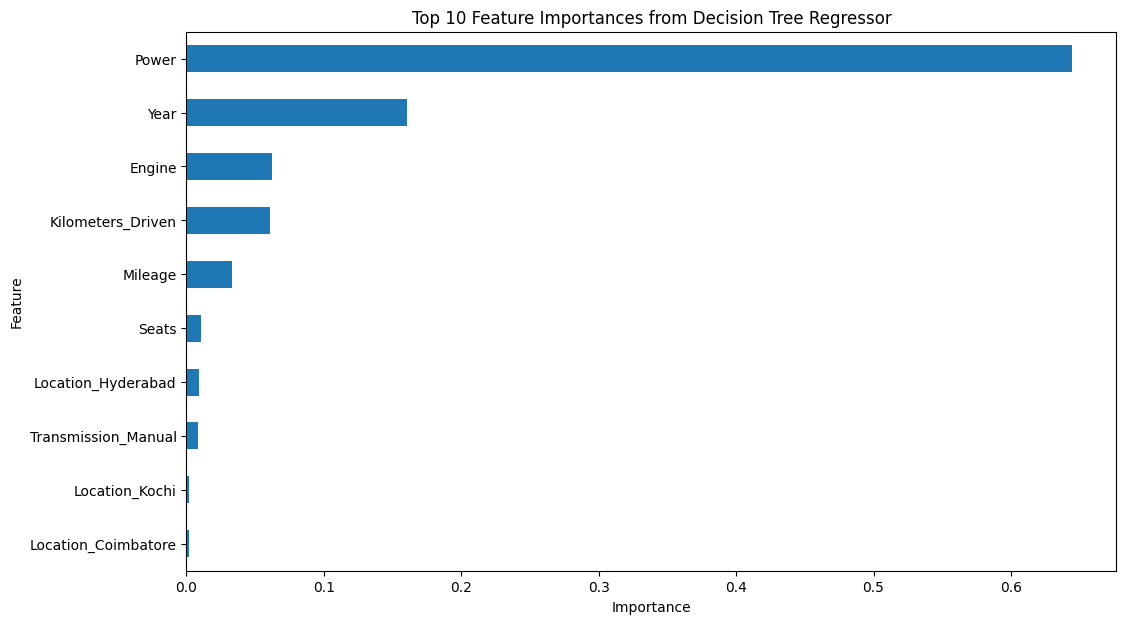

Top 10 Feature Importances:
Power                  0.644497
Year                   0.160405
Engine                 0.062468
Kilometers_Driven      0.060903
Mileage                0.032853
Seats                  0.010259
Location_Hyderabad     0.009236
Transmission_Manual    0.008091
Location_Kochi         0.001994
Location_Coimbatore    0.001898
dtype: float64


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
feature_importances = dt_regressor.feature_importances_

# Create a pandas Series for better visualization
features_df = pd.Series(feature_importances, index=X_train.columns)

# Sort features by importance
features_df = features_df.sort_values(ascending=False)

# Plot the top N feature importances (e.g., top 10)
plt.figure(figsize=(12, 7))
features_df.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances from Decision Tree Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # To have the most important feature at the top
plt.show()

print("Top 10 Feature Importances:")
print(features_df.head(10))

### Price Distribution by Owner Type

Let's visualize the distribution of 'Price' for different 'Owner_Type' categories using a box plot to understand if 'First Owner' cars generally have higher prices.

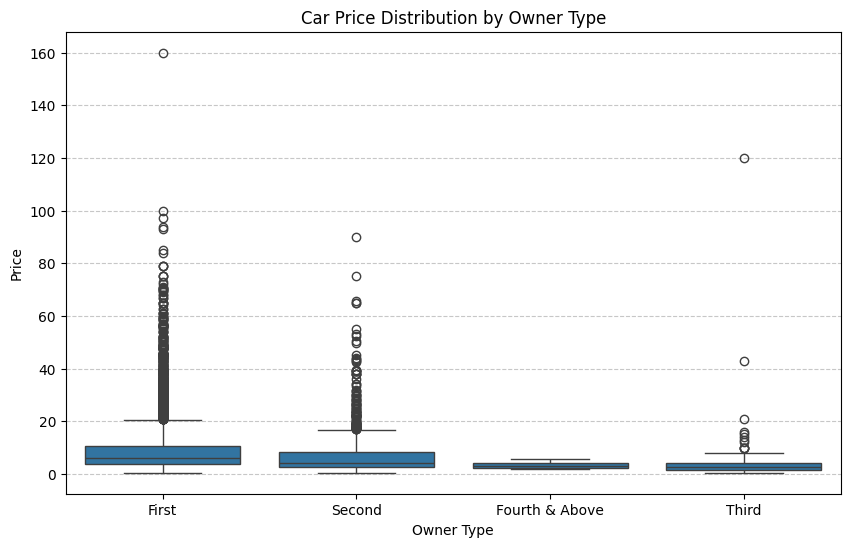

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Owner_Type', y='Price', data=df)
plt.title('Car Price Distribution by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
average_price_by_owner = df.groupby('Owner_Type')['Price'].mean().sort_values(ascending=False)
display(average_price_by_owner)

,Price
Owner_Type,
First,9.962445
Second,7.599886
Third,5.007257
Fourth & Above,3.280000
